# CEED Tensor & Patch Visualization

This notebook allows quick visualization of:
- Yearly 5×512×512 CEED tensors
- Extracted patches from these tensors

It supports multiple channels:
1. Earthquake density
2. Fault map
3. Sedimentary lithology
4. Volcanic lithology
5. Crystalline lithology

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

In [36]:
def show_tensor(tensor, title="Tensor", channel_names=None, vmax=None):
    """
    Display all channels of a 5-channel spatial tensor, each on a separate line.
    """
    n_channels, H, W = tensor.shape
    if channel_names is None:
        channel_names = [f"Ch {i}" for i in range(n_channels)]

    fig, axes = plt.subplots(n_channels, 1, figsize=(4, 4*n_channels))
    if n_channels == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        im = ax.imshow(tensor[i], origin="upper", cmap="viridis", vmax=vmax)
        ax.set_title(channel_names[i])
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def show_patch_grid(patches, n_cols=8, channel=0, title="Patch Grid"):
    """
    Display a grid of patches for a single channel.
    """
    N, C, H, W = patches.shape
    n_rows = int(np.ceil(N / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*2, n_rows*2))
    axes = axes.flatten()

    for i in range(len(axes)):
        ax = axes[i]
        if i < N:
            ax.imshow(patches[i, channel], origin="upper", cmap="viridis")
        ax.axis("off")

    plt.suptitle(title)
    plt.show()


In [37]:
# Load precomputed tensors and patches
tensor_path = Path("data/processed/cal_maps/tensor_2001.npy")
patches_path = Path("data/processed/cal_maps/patches_2001.npy")


tensor = np.load(tensor_path)
patches = np.load(patches_path)

print(f"Tensor shape: {tensor.shape}")
print(f"Patches shape: {patches.shape}")

Tensor shape: (5, 400, 400)
Patches shape: (64, 5, 50, 50)


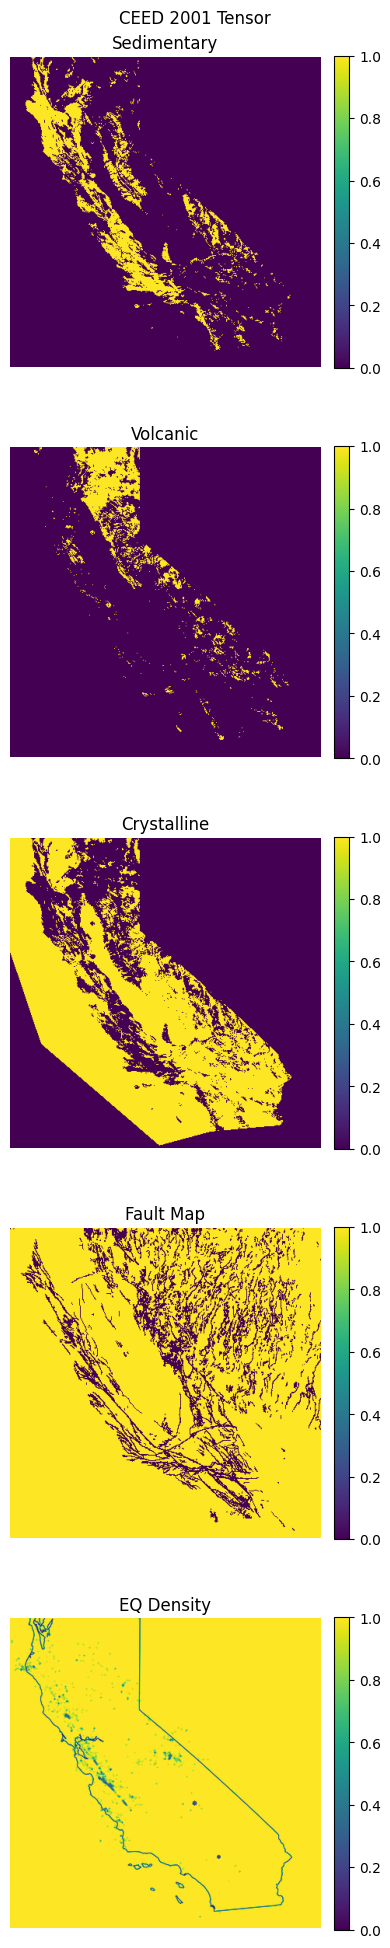

In [38]:
show_tensor(
    tensor,
    title="CEED 2001 Tensor",
    channel_names=["Sedimentary", "Volcanic", "Crystalline", "Fault Map", "EQ Density"]
)

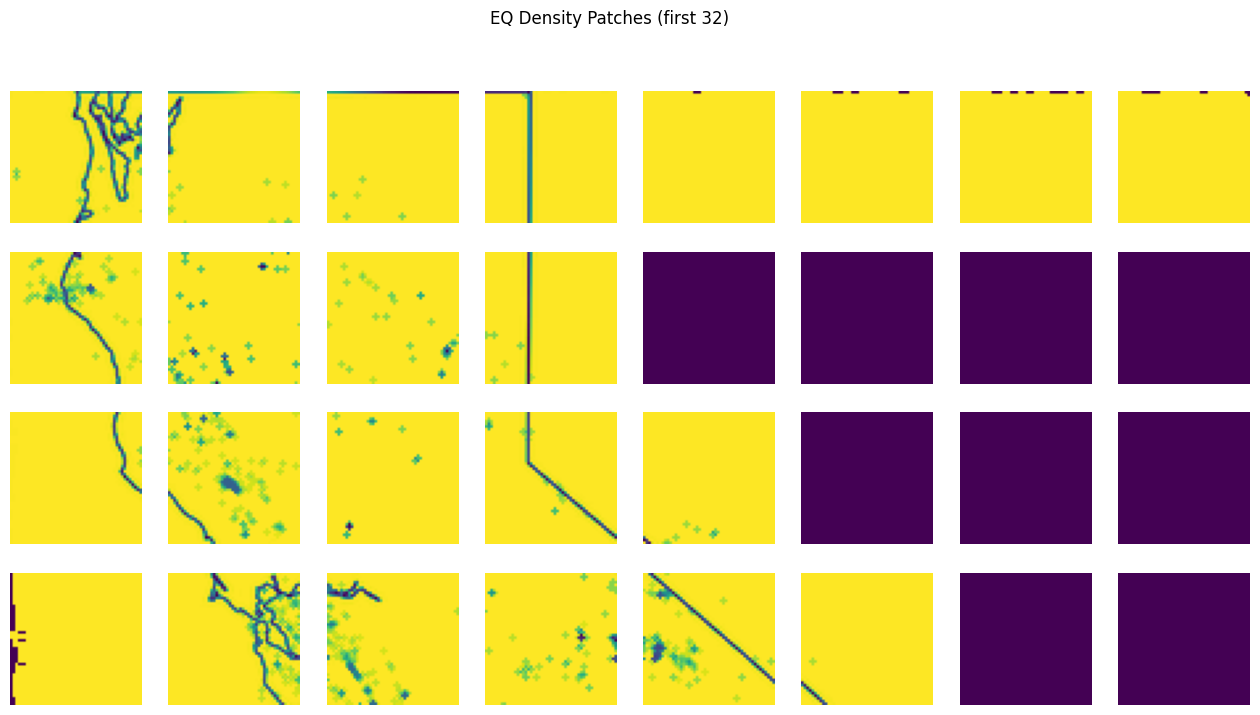

In [26]:
# Show first 32 patches of channel 4 (Earthquake density)
show_patch_grid(
    patches[:32],
    n_cols=8,
    channel=4,
    title="EQ Density Patches (first 32)"
)

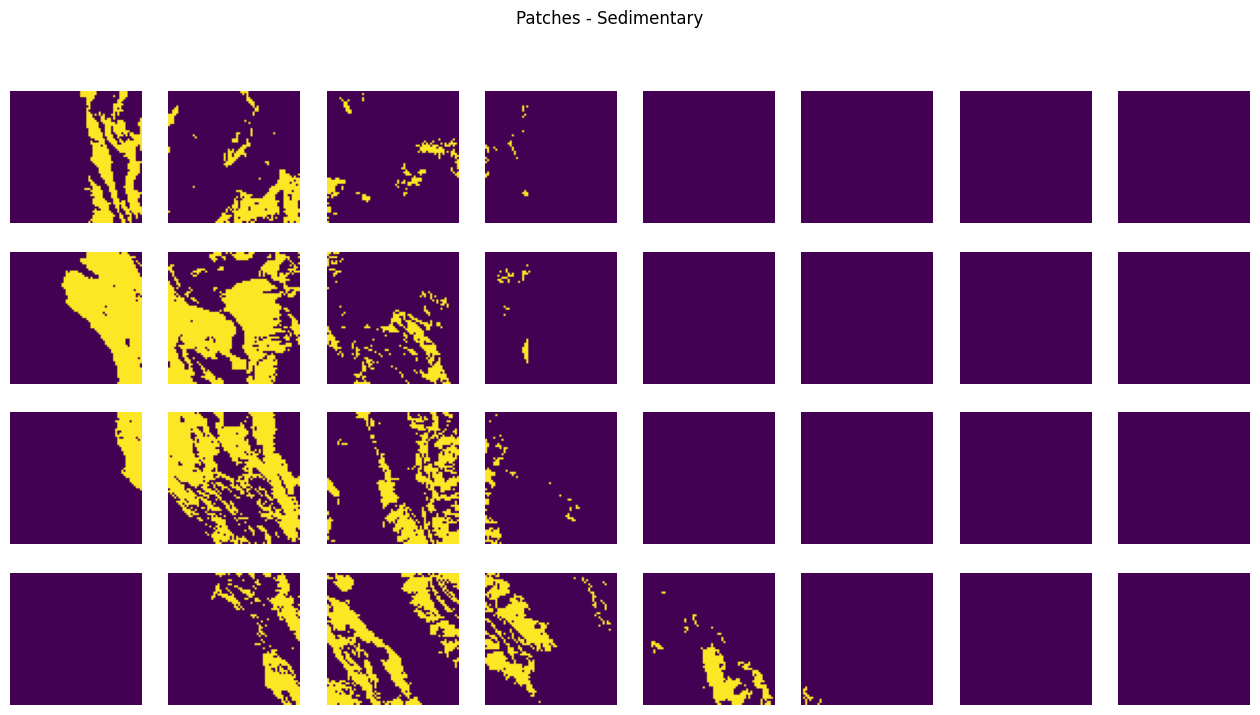

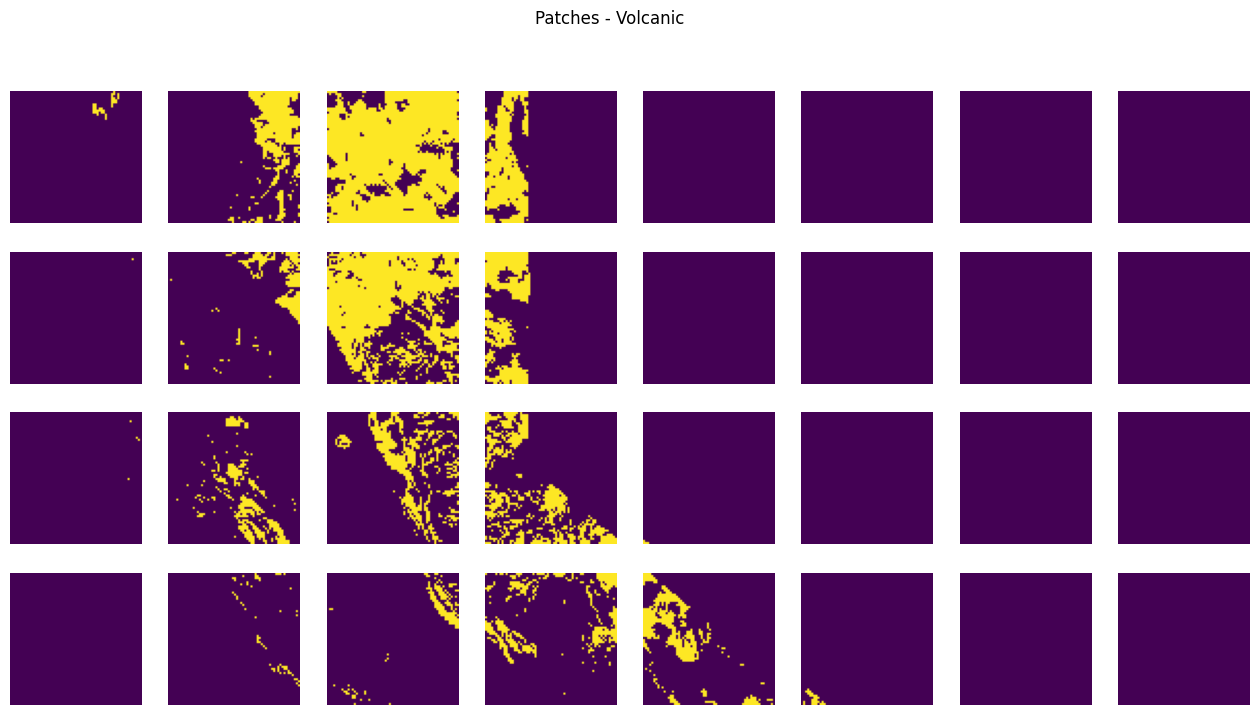

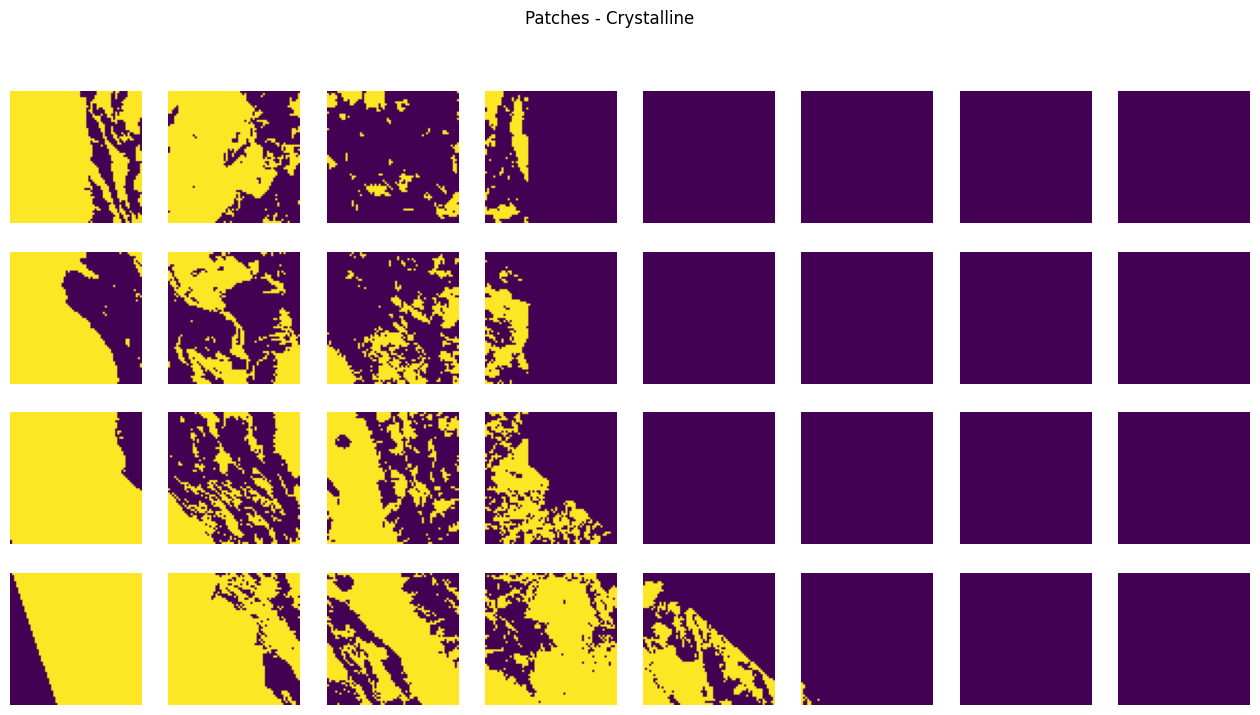

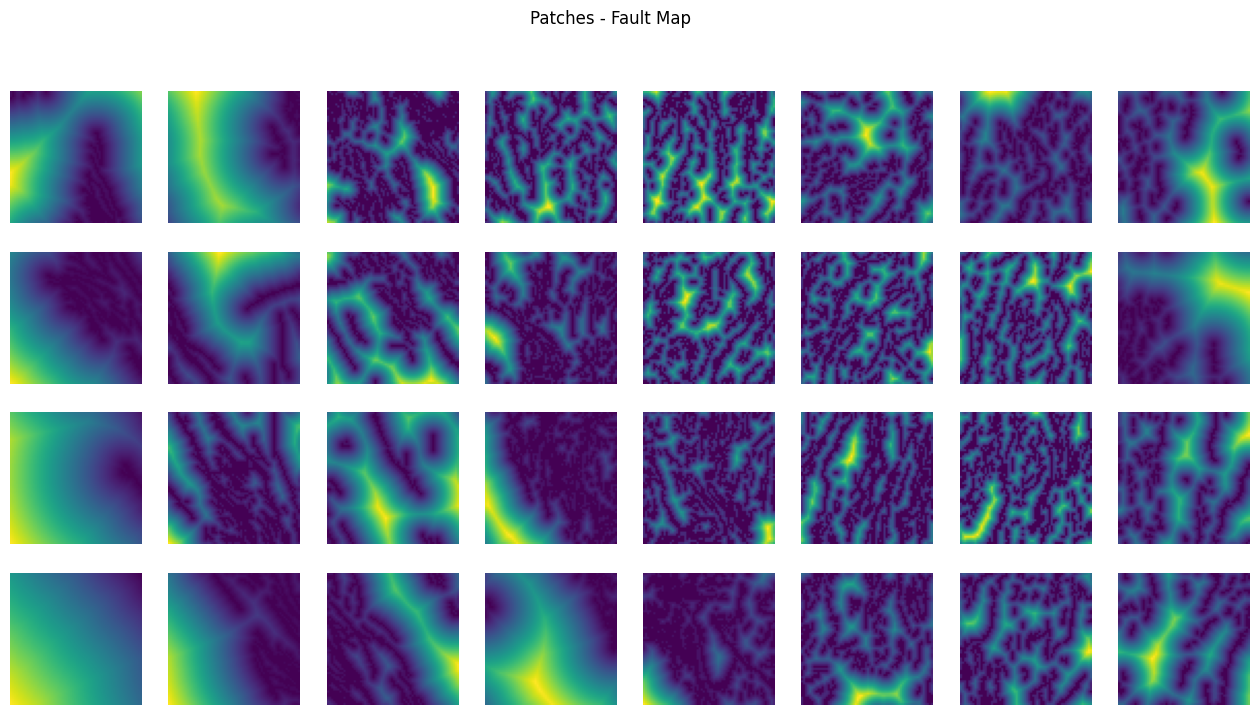

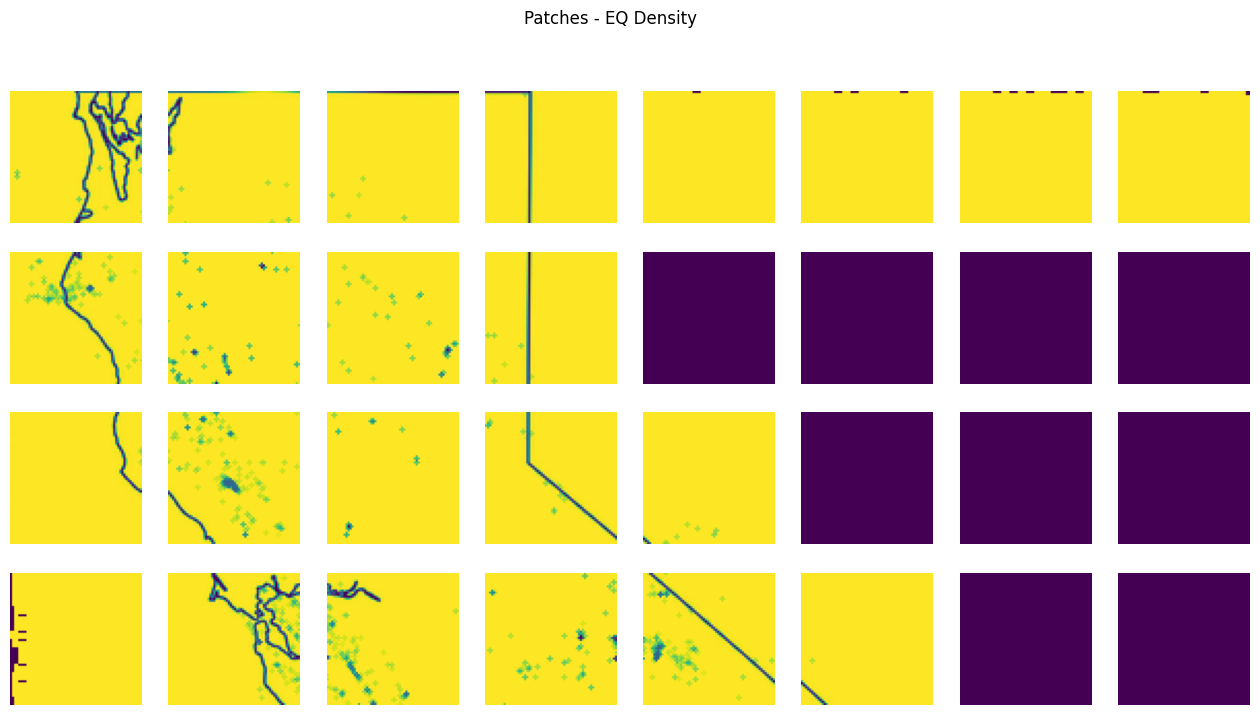

In [21]:
# Show first 5 patches line by line
for ch, name in enumerate(["Sedimentary", "Volcanic", "Crystalline", "Fault Map", "EQ Density"]):
    show_patch_grid(patches[:32], n_cols=8, channel=ch, title=f"Patches - {name}")